In [ ]:
import pandas as pd
import psycopg2
import joblib

# === Cargar modelo ===
modelo = joblib.load("/home/mercado/Documentos/Recomendador_de_suelos/APP/model/RF_pasture.joblib")

# === Conexión a PostgreSQL ===
conn = psycopg2.connect(
    dbname="TecnoGanv1",
    user="postgres",
    password="opper",
    host="15.228.233.91",
    port="5432"
)

# === Leer datos ===
query = "SELECT * FROM gestion_silvopastoril;"
df = pd.read_sql(query, conn)
conn.close()

columnas_modelo = ['ganancia_peso_agua', 'ganancia_peso_seco', 'temperatura',
       'humedad', 'potasio', 'fosforo', 'nitrogeno', 'ph', 'precipitacion']  # ← Cambia por las usadas
X = df[columnas_modelo]

# === Predecir ===
df['prediccion'] = modelo.predict(X)

# === Mostrar resultados ===
print(df[['id'] + columnas_modelo + ['prediccion']].head(10))


/home/mercado/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mercado/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


   id  ganancia_peso_agua  ganancia_peso_seco  temperatura  humedad  potasio  \
0   1                12.0                 3.0         26.0    100.0     23.0   

   fosforo  nitrogeno    ph  precipitacion prediccion  
0     12.0       22.0  33.0           22.0    Ipypora  


/tmp/ipykernel_81538/3438981153.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
/home/mercado/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [2]:
df['prediccion']

0    Ipypora
Name: prediccion, dtype: object

In [4]:
ganado = pd.read_excel('/home/mercado/Documentos/Recomendador_de_suelos/APP/data/Pasto_ganad.xlsx')
ganado

,Nombre,Ganancia_agua,Ganancia_seco
0,Tanzania,610 a 800,300 a 315
1,Mombasa,459 a 570,130 a 350
2,Masai,400 a 585,0 a 260
3,Zuri,540 a 544,271 a 250
4,Tamani,808,275
5,Quenia,554 a 700,258 a 643
6,Marandu,610 a 800,300 a 315
7,Xaraes,560 a 670,250 a 280
8,Piata,590 a 720,380
9,Paiaguas,600 a 640,420


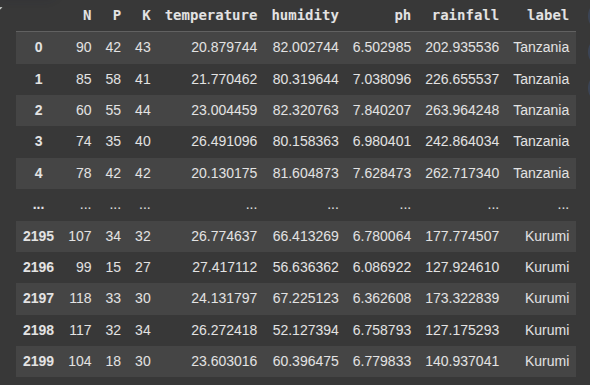